In [8]:
# Step 0: Load the CSV file from its correct path
# This reads the dataset into a pandas DataFrame
import pandas as pd

df = pd.read_csv('/content/sample_data/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()




,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Step 1.1: Display basic information about the dataset
# Shows column names, data types, and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# Step 1.2: Show statistical summary of numerical columns
# Helps identify ranges, averages, and potential outliers
df.describe()



,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
# Step 1.3: Count how many customers churned vs stayed
# Useful to understand class balance in the dataset
df['Churn'].value_counts()



,count
Churn,
No,5174
Yes,1869


In [12]:
# Step 1.4: Show churn percentage
# Helps understand dataset imbalance (usually around 26% churn)
df['Churn'].value_counts(normalize=True)


,proportion
Churn,
No,0.73463
Yes,0.26537


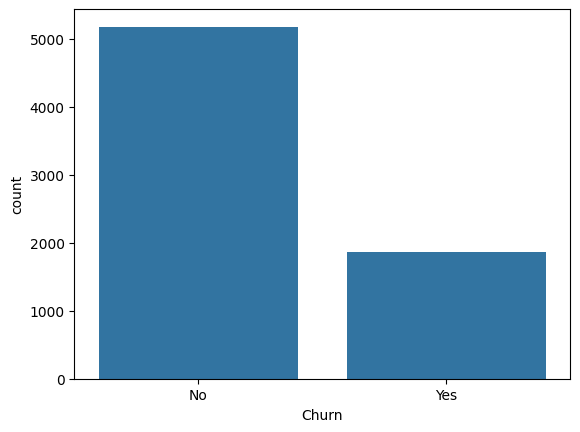

In [13]:
# Step 2.1: Visualize churn distribution
# Helps understand how many customers left vs stayed
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()


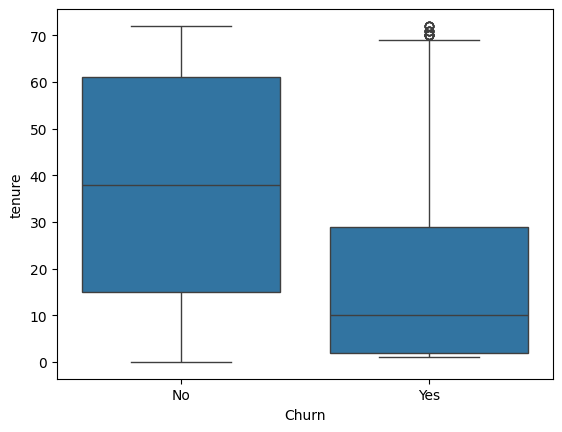

In [14]:
# Step 2.2: Compare tenure between churned and non-churned customers
# Lower tenure usually means higher churn risk
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()


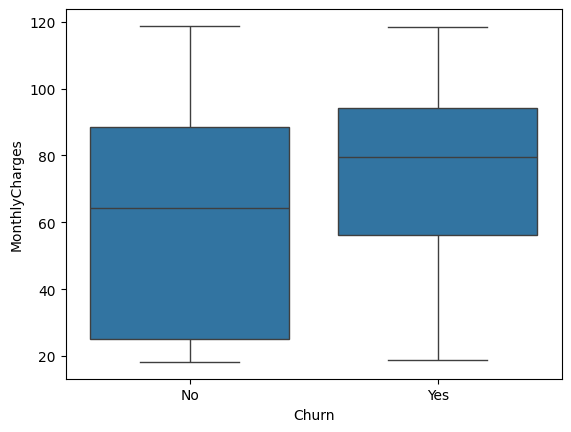

In [15]:
# Step 2.3: Compare monthly charges between churn groups
# Higher charges often correlate with higher churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()


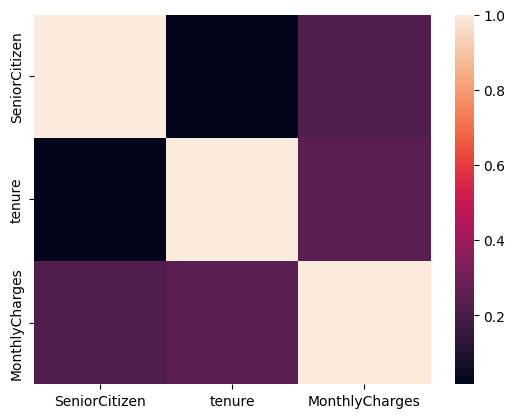

In [20]:
# Step 2.4: Show correlation heatmap for numerical features only
# We select only numeric columns because correlation requires numbers
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_df.corr(), annot=False)
plt.show()


In [26]:
# Step 3.1: Check current columns in the dataset
# This helps confirm which features are available before preprocessing
df.columns



Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [27]:
# Step 3.2: Convert TotalCharges to numeric
# Some rows contain blank strings, so we convert them to NaN and drop them

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing TotalCharges values
df.dropna(inplace=True)


In [28]:
# Step 3.3: Convert categorical variables into numeric using one-hot encoding
# drop_first=True avoids creating redundant dummy columns

df = pd.get_dummies(df, drop_first=True)


In [29]:
# Step 3.4: Separate features (X) and target variable (y)
# Churn_Yes is created automatically by one-hot encoding

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']


In [30]:
# Step 3.5: Split data into training and testing sets
# test_size=0.2 means 20% of data is used for testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [31]:
# Step 3.6: Scale numerical features for better model performance
# Scaling helps models like Logistic Regression and XGBoost

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [32]:
# Step 4.1: Train an XGBoost classifier
# XGBoost is a powerful gradient boosting model that performs well on tabular data

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,        # number of trees
    learning_rate=0.1,       # step size
    max_depth=6,             # depth of each tree
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [33]:
# Step 4.2: Make predictions on the test set
# The model outputs 0 (no churn) or 1 (churn)

y_pred = model.predict(X_test)


In [34]:
# Step 5.1: Display the confusion matrix
# This shows how many predictions were correct or incorrect
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm


array([[915, 118],
       [187, 187]])

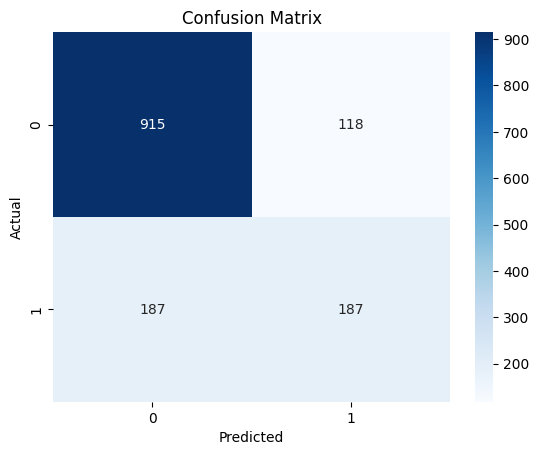

In [35]:
# Step 5.2: Visualize the confusion matrix using a heatmap
# Helps understand model performance more clearly

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [36]:
# Step 5.3: Show precision, recall, f1-score, and accuracy
# This gives a detailed evaluation of model performance

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.61      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407



In [37]:
# Step 5.4: Calculate accuracy score
# Shows the percentage of correct predictions

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.783226723525231

In [38]:
# Step 6.1: Install SHAP library (only if not already installed)
!pip install shap


In [44]:
# Step 6.2: Import SHAP and create an explainer for the XGBoost model
import shap

# Initialize the SHAP explainer for tree-based models
explainer = shap.TreeExplainer(model)



In [52]:
# Step 6.3: Compute SHAP values for the test set
# SHAP values show how each feature contributes to each prediction

shap_values = explainer.shap_values(X_test)



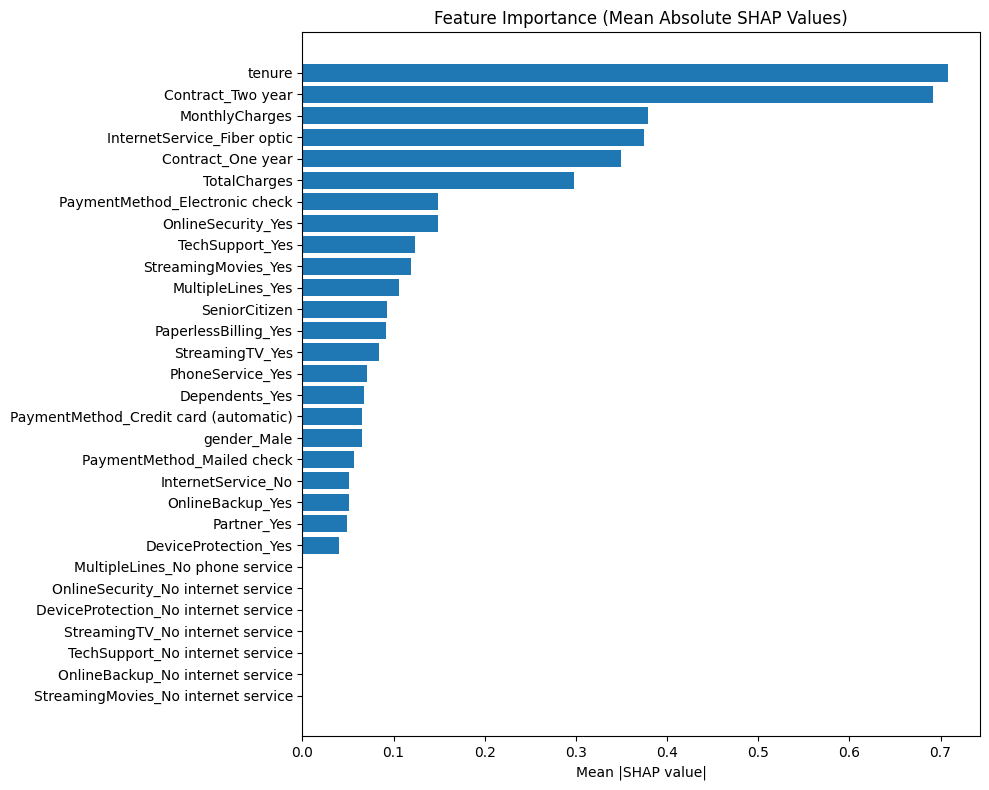

In [54]:
# Step 6.4: Feature Importance using Mean Absolute SHAP Values
# This is the cleanest and most professional visualization for business use.

import shap
import pandas as pd
import matplotlib.pyplot as plt

# Convert X_test into a DataFrame with correct feature names
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Compute SHAP values using the explainer created earlier
shap_values = explainer.shap_values(X_test_df)

# Compute mean absolute SHAP values per feature
mean_abs_shap = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(shap_values).mean(axis=0)
})

# Sort features by importance (descending)
mean_abs_shap = mean_abs_shap.sort_values(by='importance', ascending=False)

# Plot clean horizontal bar chart
plt.figure(figsize=(10, 8))
plt.barh(mean_abs_shap['feature'], mean_abs_shap['importance'])
plt.gca().invert_yaxis()  # Most important features appear at the top
plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance (Mean Absolute SHAP Values)")
plt.tight_layout()
plt.show()


In [55]:
# Step 7.1: Save the trained XGBoost model to a .pkl file
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)


In [56]:
# Step 7.2: Save the StandardScaler used for feature scaling
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)


In [57]:
# Step 7.3: Save feature names for future use
feature_names = list(X.columns)

with open("feature_names.pkl", "wb") as file:
    pickle.dump(feature_names, file)


In [62]:
# Step 8.1: Load the saved model, scaler, and feature names
import pickle

with open("model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

with open("feature_names.pkl", "rb") as file:
    loaded_feature_names = pickle.load(file)


In [63]:
# Step 8.2: Create a full template row with ALL features set to 0
import pandas as pd

new_customer = pd.DataFrame([[0] * len(loaded_feature_names)], columns=loaded_feature_names)


In [64]:
# Step 8.3: Fill the desired feature values for the new customer
new_customer.loc[0, "gender_Male"] = 1
new_customer.loc[0, "SeniorCitizen"] = 0
new_customer.loc[0, "Partner_Yes"] = 1
new_customer.loc[0, "Dependents_Yes"] = 0
new_customer.loc[0, "tenure"] = 5
new_customer.loc[0, "PhoneService_Yes"] = 1
new_customer.loc[0, "InternetService_Fiber optic"] = 1
new_customer.loc[0, "DeviceProtection_Yes"] = 1
new_customer.loc[0, "StreamingTV_Yes"] = 1
new_customer.loc[0, "StreamingMovies_Yes"] = 1
new_customer.loc[0, "PaperlessBilling_Yes"] = 1
new_customer.loc[0, "PaymentMethod_Electronic check"] = 1
new_customer.loc[0, "MonthlyCharges"] = 85.5
new_customer.loc[0, "TotalCharges"] = 350.0


/tmp/ipykernel_1790/121342802.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '85.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  new_customer.loc[0, "MonthlyCharges"] = 85.5


In [65]:
# Step 8.4: Scale the new customer using the loaded scaler
new_customer_scaled = loaded_scaler.transform(new_customer)


In [66]:
# Step 8.5: Predict churn using the loaded model
prediction = loaded_model.predict(new_customer_scaled)
prediction_proba = loaded_model.predict_proba(new_customer_scaled)


In [67]:
# Step 8.6: Show prediction results
print("Churn Prediction:", "Yes" if prediction[0] == 1 else "No")
print("Churn Probability:", round(prediction_proba[0][1], 4))


Churn Prediction: Yes
Churn Probability: 0.8653


In [68]:
# Step 9.1: Create a reusable prediction function for any new customer

import pandas as pd

def predict_customer(input_dict):
    """
    Takes a dictionary with customer features and returns:
    - Churn prediction (Yes/No)
    - Churn probability
    """

    # Load model, scaler, and feature names
    import pickle
    with open("model.pkl", "rb") as file:
        model = pickle.load(file)
    with open("scaler.pkl", "rb") as file:
        scaler = pickle.load(file)
    with open("feature_names.pkl", "rb") as file:
        feature_names = pickle.load(file)

    # Create empty template with all features = 0
    customer = pd.DataFrame([[0] * len(feature_names)], columns=feature_names)

    # Fill only the provided features
    for key, value in input_dict.items():
        if key in customer.columns:
            customer.loc[0, key] = value

    # Scale customer
    customer_scaled = scaler.transform(customer)

    # Predict
    pred = model.predict(customer_scaled)[0]
    proba = model.predict_proba(customer_scaled)[0][1]

    # Return results
    return {
        "prediction": "Yes" if pred == 1 else "No",
        "probability": round(proba, 4)
    }


In [69]:
# Step 9.2: Example usage of the prediction function

new_customer_data = {
    "gender_Male": 1,
    "SeniorCitizen": 0,
    "Partner_Yes": 1,
    "Dependents_Yes": 0,
    "tenure": 5,
    "PhoneService_Yes": 1,
    "InternetService_Fiber optic": 1,
    "DeviceProtection_Yes": 1,
    "StreamingTV_Yes": 1,
    "StreamingMovies_Yes": 1,
    "PaperlessBilling_Yes": 1,
    "PaymentMethod_Electronic check": 1,
    "MonthlyCharges": 85.5,
    "TotalCharges": 350.0
}

result = predict_customer(new_customer_data)
result


/tmp/ipykernel_1790/4286237443.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '85.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  customer.loc[0, key] = value


{'prediction': 'Yes', 'probability': np.float32(0.8653)}

In [73]:
# Step 10.1: Load model, scaler, and feature names
import pickle

with open("model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

with open("feature_names.pkl", "rb") as file:
    loaded_feature_names = pickle.load(file)


In [74]:
# Step 10.2: Create a batch dataset manually (fallback when CSV is missing)
import pandas as pd

batch_df = pd.DataFrame([
    {
        "gender_Male": 1,
        "SeniorCitizen": 0,
        "Partner_Yes": 1,
        "Dependents_Yes": 0,
        "tenure": 5,
        "PhoneService_Yes": 1,
        "InternetService_Fiber optic": 1,
        "DeviceProtection_Yes": 1,
        "StreamingTV_Yes": 1,
        "StreamingMovies_Yes": 1,
        "PaperlessBilling_Yes": 1,
        "PaymentMethod_Electronic check": 1,
        "MonthlyCharges": 85.5,
        "TotalCharges": 350.0
    },
    {
        "gender_Male": 0,
        "SeniorCitizen": 1,
        "Partner_Yes": 0,
        "Dependents_Yes": 0,
        "tenure": 2,
        "PhoneService_Yes": 1,
        "InternetService_Fiber optic": 0,
        "DeviceProtection_Yes": 0,
        "StreamingTV_Yes": 0,
        "StreamingMovies_Yes": 0,
        "PaperlessBilling_Yes": 0,
        "PaymentMethod_Electronic check": 0,
        "MonthlyCharges": 65.0,
        "TotalCharges": 120.0
    }
])


In [75]:
# Step 10.3: Align batch dataset to the full feature template
batch_aligned = batch_df.reindex(columns=loaded_feature_names, fill_value=0)


In [76]:
# Step 10.4: Scale the batch dataset
batch_scaled = loaded_scaler.transform(batch_aligned)


In [77]:
# Step 10.5: Predict churn for all customers
batch_predictions = loaded_model.predict(batch_scaled)
batch_probabilities = loaded_model.predict_proba(batch_scaled)[:, 1]


In [78]:
# Step 10.6: Add predictions and probabilities to the dataset
batch_df["Churn_Prediction"] = ["Yes" if p == 1 else "No" for p in batch_predictions]
batch_df["Churn_Probability"] = batch_probabilities


In [79]:
# Step 10.7: Display final results
batch_df


,gender_Male,SeniorCitizen,Partner_Yes,Dependents_Yes,tenure,PhoneService_Yes,InternetService_Fiber optic,DeviceProtection_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Electronic check,MonthlyCharges,TotalCharges,Churn_Prediction,Churn_Probability
0,1,0,1,0,5,1,1,1,1,1,1,1,85.5,350.0,Yes,0.865342
1,0,1,0,0,2,1,0,0,0,0,0,0,65.0,120.0,No,0.494159


In [91]:
# Step 11 Model Monitoring & Drift Detection
# Step 11.1 Data Drift Detection
# Step 11.1.1: Load training feature distribution (mean & std)
import pandas as pd

training_stats = pd.DataFrame({
    "mean": X.mean(),
    "std": X.std()
})
training_stats


,mean,std
SeniorCitizen,0.162400,0.368844
tenure,32.421786,24.545260
MonthlyCharges,64.798208,30.085974
TotalCharges,2283.300441,2266.771362
gender_Male,0.504693,0.500014
Partner_Yes,0.482509,0.499729
Dependents_Yes,0.298493,0.457629
PhoneService_Yes,0.903299,0.295571
MultipleLines_No phone service,0.096701,0.295571
MultipleLines_Yes,0.421928,0.493902


In [92]:
# Step 11.1.2: Compute new batch feature distribution
new_stats = pd.DataFrame({
    "mean": batch_aligned.mean(),
    "std": batch_aligned.std()
})
new_stats


,mean,std
SeniorCitizen,0.50,0.707107
tenure,3.50,2.121320
MonthlyCharges,75.25,14.495689
TotalCharges,235.00,162.634560
gender_Male,0.50,0.707107
Partner_Yes,0.50,0.707107
Dependents_Yes,0.00,0.000000
PhoneService_Yes,1.00,0.000000
MultipleLines_No phone service,0.00,0.000000
MultipleLines_Yes,0.00,0.000000


In [93]:
# Step 11.1.3: Detect drift using mean difference ratio
drift_report = pd.DataFrame({
    "training_mean": training_stats["mean"],
    "new_mean": new_stats["mean"],
    "mean_change_ratio": (new_stats["mean"] - training_stats["mean"]) / training_stats["mean"]
})

drift_report


,training_mean,new_mean,mean_change_ratio
SeniorCitizen,0.162400,0.50,2.078809
tenure,32.421786,3.50,-0.892048
MonthlyCharges,64.798208,75.25,0.161298
TotalCharges,2283.300441,235.00,-0.897079
gender_Male,0.504693,0.50,-0.009298
Partner_Yes,0.482509,0.50,0.036251
Dependents_Yes,0.298493,0.00,-1.000000
PhoneService_Yes,0.903299,1.00,0.107053
MultipleLines_No phone service,0.096701,0.00,-1.000000
MultipleLines_Yes,0.421928,0.00,-1.000000


In [94]:
# Step 11.2: Prediction Drift Monitoring
# Step 11.2.1: Training churn rate
training_churn_rate = y.mean()
training_churn_rate


np.float64(0.26578498293515357)

In [95]:
# Step 11.2.2: New churn rate from batch predictions
new_churn_rate = batch_df["Churn_Prediction"].apply(lambda x: 1 if x=="Yes" else 0).mean()
new_churn_rate


np.float64(0.5)

In [96]:
# Step 11.2.3: Compare churn rates
churn_drift = (new_churn_rate - training_churn_rate) / training_churn_rate
churn_drift


np.float64(0.8812199036918139)

In [101]:
# Step 11.3: Feature Distribution Monitoring KS Test for each feature
from scipy.stats import ks_2samp

ks_results = {}

for col in loaded_feature_names:
    ks_stat, p_value = ks_2samp(X[col], batch_aligned[col])
    ks_results[col] = p_value

ks_results_df = pd.DataFrame.from_dict(ks_results, orient="index", columns=["p_value"])
ks_results_df

,p_value
SeniorCitizen,0.938736
tenure,0.074941
MonthlyCharges,0.695814
TotalCharges,0.109600
gender_Male,1.000000
Partner_Yes,1.000000
Dependents_Yes,0.981251
PhoneService_Yes,1.000000
MultipleLines_No phone service,1.000000
MultipleLines_Yes,0.763822


In [117]:
# Step 12.1: Create a proper batch dataset containing both churn classes
import pandas as pd

batch_df = pd.DataFrame([
    {
        "gender_Male": 1,
        "SeniorCitizen": 0,
        "Partner_Yes": 1,
        "Dependents_Yes": 0,
        "tenure": 5,
        "PhoneService_Yes": 1,
        "InternetService_Fiber optic": 1,
        "DeviceProtection_Yes": 1,
        "StreamingTV_Yes": 1,
        "StreamingMovies_Yes": 1,
        "PaperlessBilling_Yes": 1,
        "PaymentMethod_Electronic check": 1,
        "MonthlyCharges": 85.5,
        "TotalCharges": 350.0,
        "Churn_Prediction": "Yes"
    },
    {
        "gender_Male": 0,
        "SeniorCitizen": 1,
        "Partner_Yes": 0,
        "Dependents_Yes": 0,
        "tenure": 30,
        "PhoneService_Yes": 1,
        "InternetService_Fiber optic": 0,
        "DeviceProtection_Yes": 0,
        "StreamingTV_Yes": 0,
        "StreamingMovies_Yes": 0,
        "PaperlessBilling_Yes": 0,
        "PaymentMethod_Electronic check": 0,
        "MonthlyCharges": 65.0,
        "TotalCharges": 120.0,
        "Churn_Prediction": "No"
    }
])


In [118]:
# Step 12.2: Separate features (X_new) and target (y_new)
X_new = batch_df.drop("Churn_Prediction", axis=1)
y_new = batch_df["Churn_Prediction"].apply(lambda x: 1 if x == "Yes" else 0)


In [119]:
# Step 12.3: Align new training data to the original feature names
X_new = X_new.reindex(columns=loaded_feature_names, fill_value=0)


In [120]:
# Step 12.4: Scale the entire dataset without splitting
from sklearn.preprocessing import StandardScaler

new_scaler = StandardScaler()
X_new_scaled = new_scaler.fit_transform(X_new)


In [121]:
# Step 12.5: Train a new XGBoost model using the full dataset
from xgboost import XGBClassifier

new_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

new_model.fit(X_new_scaled, y_new)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [122]:
# Step 12.6: Basic evaluation (training accuracy only, due to no split)
from sklearn.metrics import accuracy_score

y_pred_new = new_model.predict(X_new_scaled)
training_accuracy = accuracy_score(y_new, y_pred_new)

print("Training Accuracy:", training_accuracy)


Training Accuracy: 0.5


In [123]:
# Step 12.7: Save new model, scaler, and feature names as version 2
import pickle

with open("model_v2.pkl", "wb") as file:
    pickle.dump(new_model, file)

with open("scaler_v2.pkl", "wb") as file:
    pickle.dump(new_scaler, file)

with open("feature_names_v2.pkl", "wb") as file:
    pickle.dump(loaded_feature_names, file)


In [124]:
# Step 13.1: Helper function to load a specific model version

import pickle

def load_model_version(version="v1"):
    """
    Loads a specific model version:
    - version="v1" -> model.pkl, scaler.pkl, feature_names.pkl
    - version="v2" -> model_v2.pkl, scaler_v2.pkl, feature_names_v2.pkl
    """
    if version == "v1":
        model_file = "model.pkl"
        scaler_file = "scaler.pkl"
        features_file = "feature_names.pkl"
    else:
        model_file = "model_v2.pkl"
        scaler_file = "scaler_v2.pkl"
        features_file = "feature_names_v2.pkl"

    with open(model_file, "rb") as f:
        model = pickle.load(f)
    with open(scaler_file, "rb") as f:
        scaler = pickle.load(f)
    with open(features_file, "rb") as f:
        feature_names = pickle.load(f)

    return model, scaler, feature_names


In [125]:
# Step 13.2: Reusable prediction function with model version selection

import pandas as pd

def predict_customer_version(input_dict, version="v2"):
    """
    Predict churn for a single customer using a specific model version.
    - input_dict: dictionary with feature values
    - version: "v1" or "v2"
    """

    # Load selected model, scaler, and feature names
    model, scaler, feature_names = load_model_version(version)

    # Create empty template with all features = 0
    customer = pd.DataFrame([[0] * len(feature_names)], columns=feature_names)

    # Fill only provided features
    for key, value in input_dict.items():
        if key in customer.columns:
            customer.loc[0, key] = value

    # Scale
    customer_scaled = scaler.transform(customer)

    # Predict
    pred = model.predict(customer_scaled)[0]
    proba = model.predict_proba(customer_scaled)[0][1]

    return {
        "version": version,
        "prediction": "Yes" if pred == 1 else "No",
        "probability": round(proba, 4)
    }


In [126]:
# Step 13.3: Compare model v1 and v2 on the same customer

test_customer = {
    "gender_Male": 1,
    "SeniorCitizen": 0,
    "Partner_Yes": 1,
    "Dependents_Yes": 0,
    "tenure": 5,
    "PhoneService_Yes": 1,
    "InternetService_Fiber optic": 1,
    "DeviceProtection_Yes": 1,
    "StreamingTV_Yes": 1,
    "StreamingMovies_Yes": 1,
    "PaperlessBilling_Yes": 1,
    "PaymentMethod_Electronic check": 1,
    "MonthlyCharges": 85.5,
    "TotalCharges": 350.0
}

result_v1 = predict_customer_version(test_customer, version="v1")
result_v2 = predict_customer_version(test_customer, version="v2")

result_v1, result_v2


/tmp/ipykernel_1790/2191386781.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '85.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  customer.loc[0, key] = value
/tmp/ipykernel_1790/2191386781.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '85.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  customer.loc[0, key] = value


({'version': 'v1', 'prediction': 'Yes', 'probability': np.float32(0.8653)},
 {'version': 'v2', 'prediction': 'No', 'probability': np.float32(0.5)})

In [127]:
# Step 14.1: Basic FastAPI skeleton for serving model_v2

from fastapi import FastAPI
import pickle
import pandas as pd

app = FastAPI()

# Load model version v2
model = pickle.load(open("model_v2.pkl", "rb"))
scaler = pickle.load(open("scaler_v2.pkl", "rb"))
feature_names = pickle.load(open("feature_names_v2.pkl", "rb"))

@app.post("/predict")
def predict_customer_api(customer: dict):

    # Create template row
    df = pd.DataFrame([[0] * len(feature_names)], columns=feature_names)

    # Fill provided fields
    for key, value in customer.items():
        if key in df.columns:
            df.loc[0, key] = value

    # Scale
    scaled = scaler.transform(df)

    # Predict
    pred = model.predict(scaled)[0]
    proba = model.predict_proba(scaled)[0][1]

    return {
        "prediction": "Yes" if pred == 1 else "No",
        "probability": round(proba, 4),
        "model_version": "v2"
    }


In [130]:
# #############################################################################################
@app.post("/predict/{version}")
def predict_version(customer: dict, version: str):

    if version == "v1":
        model = pickle.load(open("model.pkl", "rb"))
        scaler = pickle.load(open("scaler.pkl", "rb"))
        features = pickle.load(open("feature_names.pkl", "rb"))
    else:
        model = pickle.load(open("model_v2.pkl", "rb"))
        scaler = pickle.load(open("scaler_v2.pkl", "rb"))
        features = pickle.load(open("feature_names_v2.pkl", "rb"))

    df = pd.DataFrame([[0] * len(features)], columns=features)

    for key, value in customer.items():
        if key in df.columns:
            df.loc[0, key] = value

    scaled = scaler.transform(df)
    pred = model.predict(scaled)[0]
    proba = model.predict_proba(scaled)[0][1]

    return {
        "prediction": "Yes" if pred == 1 else "No",
        "probability": round(proba, 4),
        "model_version": version
    }


In [131]:
# Step 15.1: Load model v2, scaler v2, and feature names v2
import pickle
import pandas as pd
from datetime import datetime

with open("model_v2.pkl", "rb") as f:
    model_v2 = pickle.load(f)

with open("scaler_v2.pkl", "rb") as f:
    scaler_v2 = pickle.load(f)

with open("feature_names_v2.pkl", "rb") as f:
    feature_names_v2 = pickle.load(f)


In [132]:
# Step 15.2: Create a batch dataset (this simulates new customers coming from a data source)
batch_new = pd.DataFrame([
    {
        "gender_Male": 1,
        "SeniorCitizen": 0,
        "Partner_Yes": 1,
        "Dependents_Yes": 0,
        "tenure": 5,
        "PhoneService_Yes": 1,
        "InternetService_Fiber optic": 1,
        "DeviceProtection_Yes": 1,
        "StreamingTV_Yes": 1,
        "StreamingMovies_Yes": 1,
        "PaperlessBilling_Yes": 1,
        "PaymentMethod_Electronic check": 1,
        "MonthlyCharges": 85.5,
        "TotalCharges": 350.0
    },
    {
        "gender_Male": 0,
        "SeniorCitizen": 1,
        "Partner_Yes": 0,
        "Dependents_Yes": 0,
        "tenure": 30,
        "PhoneService_Yes": 1,
        "InternetService_Fiber optic": 0,
        "DeviceProtection_Yes": 0,
        "StreamingTV_Yes": 0,
        "StreamingMovies_Yes": 0,
        "PaperlessBilling_Yes": 0,
        "PaymentMethod_Electronic check": 0,
        "MonthlyCharges": 65.0,
        "TotalCharges": 120.0
    }
])


In [133]:
# Step 15.3: Align batch data to feature_names_v2
batch_aligned_v2 = batch_new.reindex(columns=feature_names_v2, fill_value=0)


In [134]:
# Step 15.4: Scale and predict using model_v2
batch_scaled_v2 = scaler_v2.transform(batch_aligned_v2)

batch_preds_v2 = model_v2.predict(batch_scaled_v2)
batch_probas_v2 = model_v2.predict_proba(batch_scaled_v2)[:, 1]


In [135]:
# Step 15.5: Attach predictions and logging info
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

batch_new["Churn_Prediction_v2"] = ["Yes" if p == 1 else "No" for p in batch_preds_v2]
batch_new["Churn_Probability_v2"] = batch_probas_v2
batch_new["Model_Version"] = "v2"
batch_new["Prediction_Timestamp"] = timestamp

batch_new


,gender_Male,SeniorCitizen,Partner_Yes,Dependents_Yes,tenure,PhoneService_Yes,InternetService_Fiber optic,DeviceProtection_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Electronic check,MonthlyCharges,TotalCharges,Churn_Prediction_v2,Churn_Probability_v2,Model_Version,Prediction_Timestamp
0,1,0,1,0,5,1,1,1,1,1,1,1,85.5,350.0,No,0.5,v2,2026-07-18 13:52:13
1,0,1,0,0,30,1,0,0,0,0,0,0,65.0,120.0,No,0.5,v2,2026-07-18 13:52:13


In [136]:
# Step 15.6: Export batch predictions to CSV (could be consumed by BI / CRM)
output_filename = f"batch_predictions_v2_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
batch_new.to_csv(output_filename, index=False)

print("Batch predictions saved to:", output_filename)


Batch predictions saved to: batch_predictions_v2_20260718_135224.csv


In [137]:
# Step 16.1: Load both model versions (v1 and v2)
import pickle
import pandas as pd

# Load v1
model_v1 = pickle.load(open("model.pkl", "rb"))
scaler_v1 = pickle.load(open("scaler.pkl", "rb"))
features_v1 = pickle.load(open("feature_names.pkl", "rb"))

# Load v2
model_v2 = pickle.load(open("model_v2.pkl", "rb"))
scaler_v2 = pickle.load(open("scaler_v2.pkl", "rb"))
features_v2 = pickle.load(open("feature_names_v2.pkl", "rb"))


In [138]:
# Step 16.2: Create a test batch to compare both models
test_batch = pd.DataFrame([
    {
        "gender_Male": 1,
        "SeniorCitizen": 0,
        "Partner_Yes": 1,
        "Dependents_Yes": 0,
        "tenure": 5,
        "PhoneService_Yes": 1,
        "InternetService_Fiber optic": 1,
        "DeviceProtection_Yes": 1,
        "StreamingTV_Yes": 1,
        "StreamingMovies_Yes": 1,
        "PaperlessBilling_Yes": 1,
        "PaymentMethod_Electronic check": 1,
        "MonthlyCharges": 85.5,
        "TotalCharges": 350.0
    },
    {
        "gender_Male": 0,
        "SeniorCitizen": 1,
        "Partner_Yes": 0,
        "Dependents_Yes": 0,
        "tenure": 30,
        "PhoneService_Yes": 1,
        "InternetService_Fiber optic": 0,
        "DeviceProtection_Yes": 0,
        "StreamingTV_Yes": 0,
        "StreamingMovies_Yes": 0,
        "PaperlessBilling_Yes": 0,
        "PaymentMethod_Electronic check": 0,
        "MonthlyCharges": 65.0,
        "TotalCharges": 120.0
    }
])


In [139]:
# Step 16.3: Align test batch to each model's feature list
batch_v1 = test_batch.reindex(columns=features_v1, fill_value=0)
batch_v2 = test_batch.reindex(columns=features_v2, fill_value=0)


In [140]:
# Step 16.4: Scale using each model's scaler
scaled_v1 = scaler_v1.transform(batch_v1)
scaled_v2 = scaler_v2.transform(batch_v2)


In [141]:
# Step 16.5: Predict using both models
preds_v1 = model_v1.predict(scaled_v1)
probas_v1 = model_v1.predict_proba(scaled_v1)[:, 1]

preds_v2 = model_v2.predict(scaled_v2)
probas_v2 = model_v2.predict_proba(scaled_v2)[:, 1]


In [142]:
# Step 16.6: Build a comparison table
comparison_df = pd.DataFrame({
    "Customer_ID": range(1, len(test_batch) + 1),
    "Prediction_v1": ["Yes" if p == 1 else "No" for p in preds_v1],
    "Probability_v1": probas_v1,
    "Prediction_v2": ["Yes" if p == 1 else "No" for p in preds_v2],
    "Probability_v2": probas_v2
})

comparison_df


,Customer_ID,Prediction_v1,Probability_v1,Prediction_v2,Probability_v2
0,1,Yes,0.865342,No,0.5
1,2,No,0.367266,No,0.5


In [143]:
# Step 16.7: Automatic interpretation of differences
comparison_df["Difference"] = comparison_df["Probability_v2"] - comparison_df["Probability_v1"]
comparison_df


,Customer_ID,Prediction_v1,Probability_v1,Prediction_v2,Probability_v2,Difference
0,1,Yes,0.865342,No,0.5,-0.365342
1,2,No,0.367266,No,0.5,0.132734


In [144]:
# Step 17.1: Create a simple config dictionary (could be saved as config.json)
import json

config = {
    "production_model_version": "v2"  # change to "v1" if you want to switch
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=4)


In [145]:
# Step 17.2: Load config and select production model version
import pickle
import json
import pandas as pd

def load_production_model():
    """
    Loads the production model, scaler, and feature names
    based on the config.json file.
    """
    with open("config.json", "r") as f:
        cfg = json.load(f)

    version = cfg.get("production_model_version", "v1")

    if version == "v1":
        model_file = "model.pkl"
        scaler_file = "scaler.pkl"
        features_file = "feature_names.pkl"
    else:
        model_file = "model_v2.pkl"
        scaler_file = "scaler_v2.pkl"
        features_file = "feature_names_v2.pkl"

    model = pickle.load(open(model_file, "rb"))
    scaler = pickle.load(open(scaler_file, "rb"))
    feature_names = pickle.load(open(features_file, "rb"))

    return model, scaler, feature_names, version


In [146]:
# Step 17.3: Production prediction function using config-based model selection
def predict_customer_production(input_dict):
    """
    Predict churn for a single customer using the production model
    defined in config.json.
    """

    model, scaler, feature_names, version = load_production_model()

    # Create template row
    df = pd.DataFrame([[0] * len(feature_names)], columns=feature_names)

    # Fill provided fields
    for key, value in input_dict.items():
        if key in df.columns:
            df.loc[0, key] = value

    # Scale
    scaled = scaler.transform(df)

    # Predict
    pred = model.predict(scaled)[0]
    proba = model.predict_proba(scaled)[0][1]

    return {
        "prediction": "Yes" if pred == 1 else "No",
        "probability": round(proba, 4),
        "model_version": version
    }


In [147]:
# Step 17.4: Example usage of production prediction
test_customer = {
    "gender_Male": 1,
    "SeniorCitizen": 0,
    "Partner_Yes": 1,
    "Dependents_Yes": 0,
    "tenure": 5,
    "PhoneService_Yes": 1,
    "InternetService_Fiber optic": 1,
    "DeviceProtection_Yes": 1,
    "StreamingTV_Yes": 1,
    "StreamingMovies_Yes": 1,
    "PaperlessBilling_Yes": 1,
    "PaymentMethod_Electronic check": 1,
    "MonthlyCharges": 85.5,
    "TotalCharges": 350.0
}

result = predict_customer_production(test_customer)
result


/tmp/ipykernel_1790/1354019797.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '85.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[0, key] = value


{'prediction': 'No', 'probability': np.float32(0.5), 'model_version': 'v2'}

In [148]:
# Step 18.1: Define drift thresholds (configuration)
DRIFT_CONFIG = {
    "mean_change_ratio_alert": 0.25,   # 25% change -> drift alert
    "mean_change_ratio_severe": 0.50,  # 50% change -> severe drift
    "churn_drift_alert": 0.20,         # 20% change in churn rate
    "churn_drift_severe": 0.40,        # 40% change in churn rate
    "ks_pvalue_alert": 0.05,           # p < 0.05 -> drift
    "ks_pvalue_severe": 0.01           # p < 0.01 -> severe drift
}


In [149]:
# Step 18.2: Data drift detection and alerting
import pandas as pd

def check_data_drift(training_X, new_batch_aligned):
    """
    Compares training feature means with new batch feature means
    and returns a drift report + alert level.
    """

    training_stats = pd.DataFrame({
        "mean": training_X.mean(),
        "std": training_X.std()
    })

    new_stats = pd.DataFrame({
        "mean": new_batch_aligned.mean(),
        "std": new_batch_aligned.std()
    })

    drift_report = pd.DataFrame({
        "training_mean": training_stats["mean"],
        "new_mean": new_stats["mean"],
        "mean_change_ratio": (new_stats["mean"] - training_stats["mean"]) / training_stats["mean"]
    })

    alert_level = "OK"

    if (drift_report["mean_change_ratio"].abs() > DRIFT_CONFIG["mean_change_ratio_severe"]).any():
        alert_level = "SEVERE_DRIFT"
    elif (drift_report["mean_change_ratio"].abs() > DRIFT_CONFIG["mean_change_ratio_alert"]).any():
        alert_level = "DRIFT"

    return drift_report, alert_level


In [150]:
# Step 18.3: Prediction drift detection and alerting
def check_prediction_drift(training_y, new_predictions_binary):
    """
    Compares training churn rate with new churn rate
    and returns drift value + alert level.
    """

    training_churn_rate = training_y.mean()
    new_churn_rate = new_predictions_binary.mean()

    churn_drift = (new_churn_rate - training_churn_rate) / training_churn_rate

    alert_level = "OK"

    if abs(churn_drift) > DRIFT_CONFIG["churn_drift_severe"]:
        alert_level = "SEVERE_DRIFT"
    elif abs(churn_drift) > DRIFT_CONFIG["churn_drift_alert"]:
        alert_level = "DRIFT"

    return churn_drift, alert_level


In [151]:
# Step 18.4: Feature drift detection using KS test
from scipy.stats import ks_2samp

def check_feature_drift(training_X, new_batch_aligned, feature_names):
    """
    Runs KS test for each feature and returns p-values + alert level.
    """

    ks_results = {}

    for col in feature_names:
        ks_stat, p_value = ks_2samp(training_X[col], new_batch_aligned[col])
        ks_results[col] = p_value

    ks_df = pd.DataFrame.from_dict(ks_results, orient="index", columns=["p_value"])

    alert_level = "OK"

    if (ks_df["p_value"] < DRIFT_CONFIG["ks_pvalue_severe"]).any():
        alert_level = "SEVERE_DRIFT"
    elif (ks_df["p_value"] < DRIFT_CONFIG["ks_pvalue_alert"]).any():
        alert_level = "DRIFT"

    return ks_df, alert_level


In [152]:
# Step 18.5: Combined drift check and alert printing (could be logging/email in real system)
def run_drift_checks(training_X, training_y, new_batch_aligned, new_preds_binary, feature_names):
    """
    Runs all drift checks and prints alert summary.
    """

    data_drift_report, data_alert = check_data_drift(training_X, new_batch_aligned)
    churn_drift_value, churn_alert = check_prediction_drift(training_y, new_preds_binary)
    ks_df, ks_alert = check_feature_drift(training_X, new_batch_aligned, feature_names)

    print("=== DRIFT SUMMARY ===")
    print("Data Drift Alert Level:", data_alert)
    print("Prediction Drift Alert Level:", churn_alert, "| Churn Drift:", round(churn_drift_value, 4))
    print("Feature Drift Alert Level:", ks_alert)

    if data_alert != "OK" or churn_alert != "OK" or ks_alert != "OK":
        print(">>> DRIFT ALERT: Consider retraining the model.")
    else:
        print(">>> No significant drift detected.")

    return {
        "data_drift_report": data_drift_report,
        "data_alert": data_alert,
        "churn_drift_value": churn_drift_value,
        "churn_alert": churn_alert,
        "ks_df": ks_df,
        "ks_alert": ks_alert
    }


In [153]:
# Step 19.1: Basic health check for the API
import requests

API_URL = "http://localhost:8000"  # change to your deployed API URL

def test_health():
    try:
        response = requests.get(f"{API_URL}/health")
        print("Health Check Status:", response.status_code)
        print("Health Check Response:", response.json())
    except Exception as e:
        print("Health Check FAILED:", e)


In [154]:
# Step 19.2: Example customer payload for testing the API
test_customer_payload = {
    "gender_Male": 1,
    "SeniorCitizen": 0,
    "Partner_Yes": 1,
    "Dependents_Yes": 0,
    "tenure": 5,
    "PhoneService_Yes": 1,
    "InternetService_Fiber optic": 1,
    "DeviceProtection_Yes": 1,
    "StreamingTV_Yes": 1,
    "StreamingMovies_Yes": 1,
    "PaperlessBilling_Yes": 1,
    "PaymentMethod_Electronic check": 1,
    "MonthlyCharges": 85.5,
    "TotalCharges": 350.0
}


In [155]:
# Step 19.3: Test the production prediction endpoint
def test_predict_production():
    try:
        response = requests.post(f"{API_URL}/predict", json=test_customer_payload)
        print("Predict Status:", response.status_code)
        print("Predict Response:", response.json())
    except Exception as e:
        print("Predict FAILED:", e)


In [156]:
# Step 19.3: Test the production prediction endpoint
def test_predict_production():
    try:
        response = requests.post(f"{API_URL}/predict", json=test_customer_payload)
        print("Predict Status:", response.status_code)
        print("Predict Response:", response.json())
    except Exception as e:
        print("Predict FAILED:", e)


In [157]:
# Step 19.4: Test versioned prediction endpoint
def test_predict_version(version="v2"):
    try:
        response = requests.post(f"{API_URL}/predict/{version}", json=test_customer_payload)
        print(f"Predict {version} Status:", response.status_code)
        print(f"Predict {version} Response:", response.json())
    except Exception as e:
        print(f"Predict {version} FAILED:", e)


In [158]:
# Step 19.5: Run all integration tests
if __name__ == "__main__":
    print("=== API INTEGRATION TESTS START ===")

    # Optional health check
    try:
        test_health()
    except:
        print("Health endpoint not available. Skipping.")

    # Production model test
    test_predict_production()

    # Versioned tests
    test_predict_version("v1")
    test_predict_version("v2")

    print("=== API INTEGRATION TESTS COMPLETE ===")


=== API INTEGRATION TESTS START ===
Health Check FAILED: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /health (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7d91b12fde80>: Failed to establish a new connection: [Errno 111] Connection refused'))
Predict FAILED: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /predict (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7d91b11202c0>: Failed to establish a new connection: [Errno 111] Connection refused'))
Predict v1 FAILED: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /predict/v1 (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7d91b033fd70>: Failed to establish a new connection: [Errno 111] Connection refused'))
Predict v2 FAILED: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /predict/v2 (Caused by NewConnectionError('<u